# import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp

# Load Dataset

In [2]:
df=pd.read_csv('Task 1/archive/student_performance.csv')
df

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A
...,...,...,...,...,...,...
999995,999996,18.0,95.5,4.8,100.0,A
999996,999997,15.7,82.7,6.7,88.3,A
999997,999998,14.2,85.1,5.8,87.9,A
999998,999999,25.3,90.0,5.3,100.0,A


In [3]:
df.shape

(1000000, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


In [5]:
df.isnull()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
999995,False,False,False,False,False,False
999996,False,False,False,False,False,False
999997,False,False,False,False,False,False
999998,False,False,False,False,False,False


## check missing values

In [6]:
df.isnull().sum()

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [7]:
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278932,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


# Drop unnecesary column

In [8]:
df=df.drop('student_id', axis=1)

# OBSERVATIONS: 
Large number of rows.  
no misssing value exist.  
Drop student_id bcz it has no impact on pridiction.

## import labelencoder for encoding target variable

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
le = LabelEncoder()
df['grade'] = le.fit_transform(df['grade'])

In [11]:
df.head()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,18.5,95.6,3.8,97.9,0
1,14.0,80.0,2.5,83.9,1
2,19.5,86.3,5.3,100.0,0
3,25.7,70.2,7.0,100.0,0
4,13.4,81.9,6.9,92.0,0


# OBSERVATIONS:  
Categorical target(grade) converteed into numerical form  
Bcz required for machine learning models.

# EDA  
## Data visualisation by Histogram

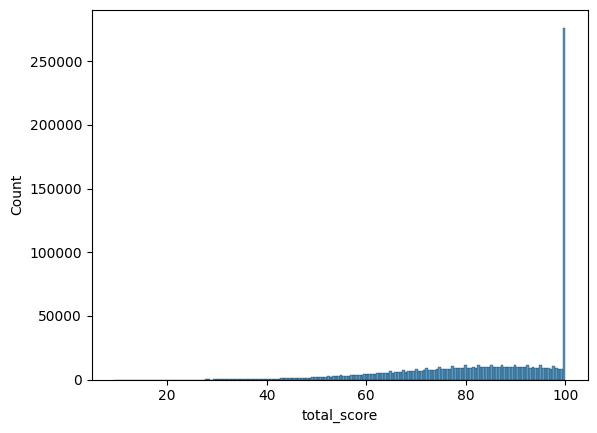

In [12]:
sns.histplot(df['total_score'])
plt.show()

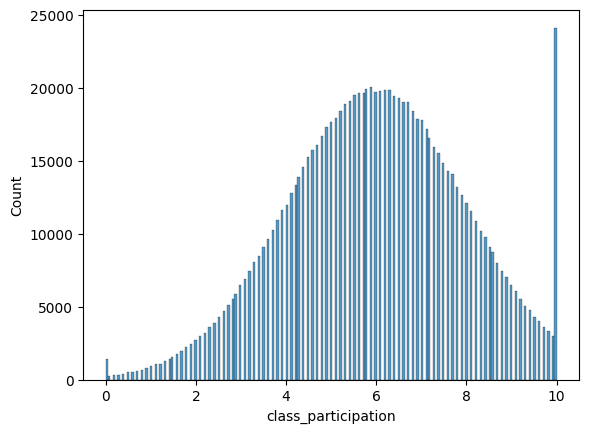

In [13]:
sns.histplot(df['class_participation'])
plt.show()

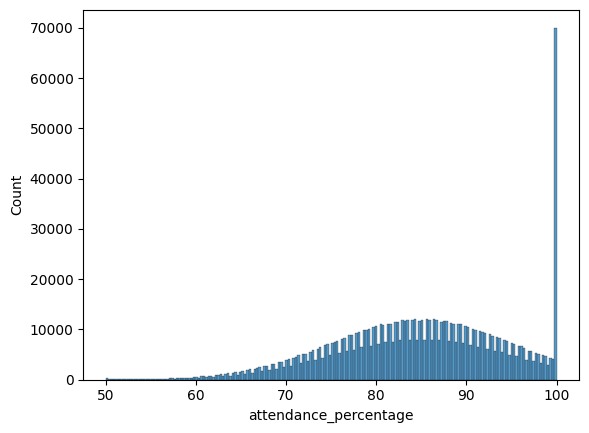

In [14]:
sns.histplot(df['attendance_percentage'])
plt.show()

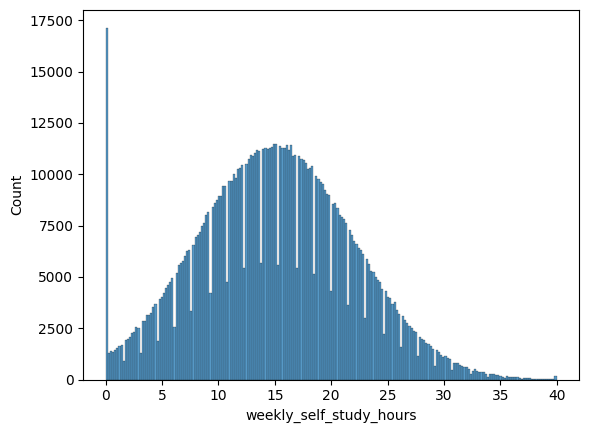

In [15]:
sns.histplot(df['weekly_self_study_hours'])
plt.show()

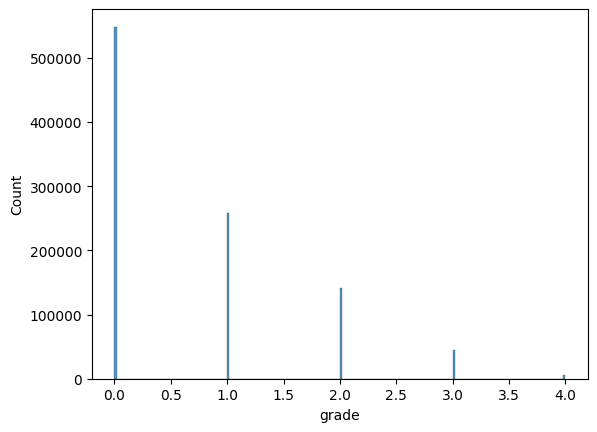

In [16]:
sns.histplot(df['grade'])
plt.show()

# OBSERVATION  


# Check outliers by boxplot

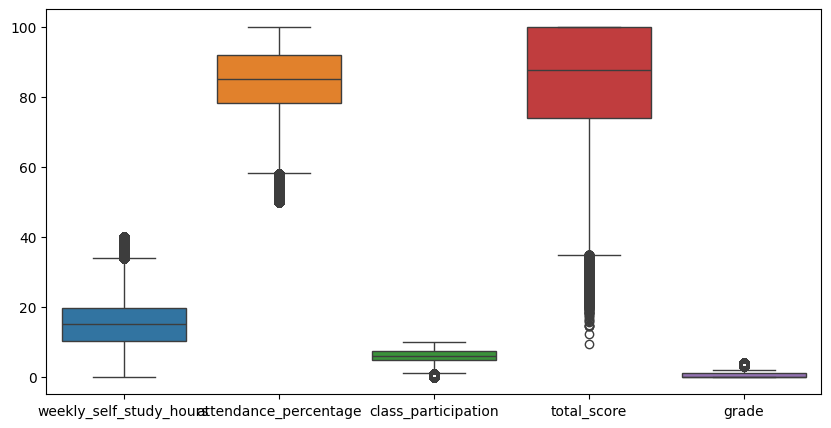

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.show()

## Handle outliers by IQR method

In [21]:
cols = ['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']
for col in cols:
    q1, q3 = df[col].quantile([.25, .75])
    df = df[df[col].between(q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1))]
print(f"Total rows removed: {1000000 - len(df)}") 

Total rows removed: 13825


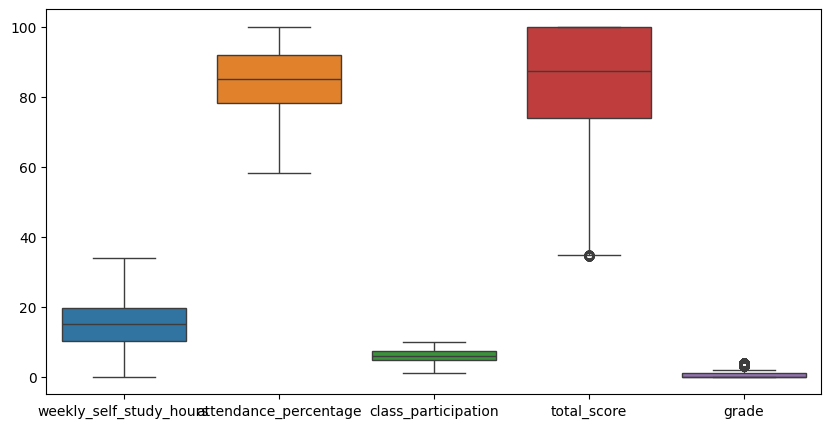

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df) 
plt.show()

## OBSERVATION:   
Very few outliers are present   
Then handle with IQR method  
Now boxplot shows a clean distribution

## Check scaterplot

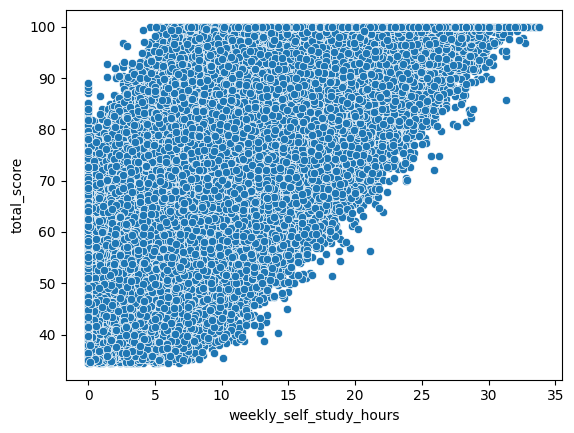

In [24]:
# study hours vs score
sns.scatterplot(x=df['weekly_self_study_hours'], y=df['total_score'])
plt.show()

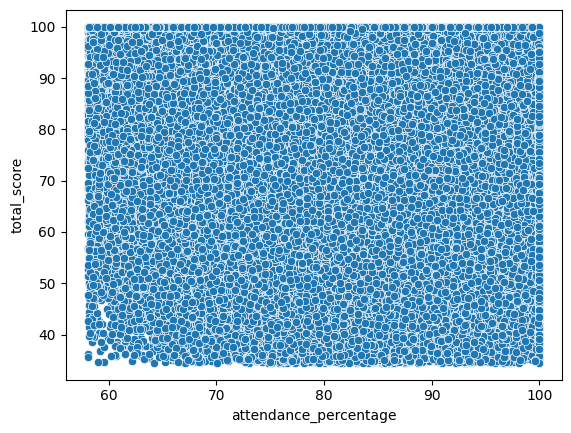

In [25]:
# attendance vs score
sns.scatterplot(x=df['attendance_percentage'], y=df['total_score'])
plt.show()

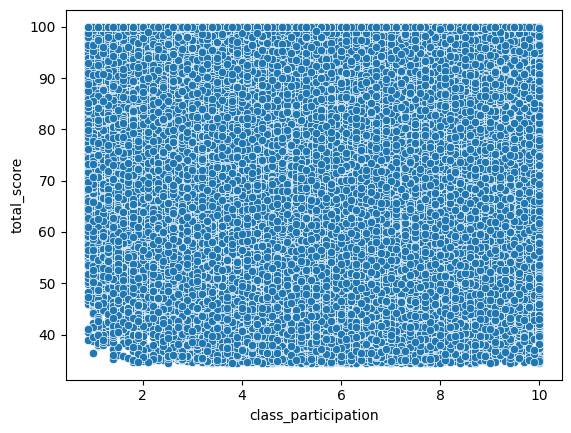

In [26]:
# participation vs score
sns.scatterplot(x=df['class_participation'], y=df['total_score'])
plt.show()

## OBSERVATION:  
Positive relationship: higher study hours, attendance, and participation lead to higher scores.   
Data shows a clear upward trend with no major inconsistencies.

# check Corelation Heatmap

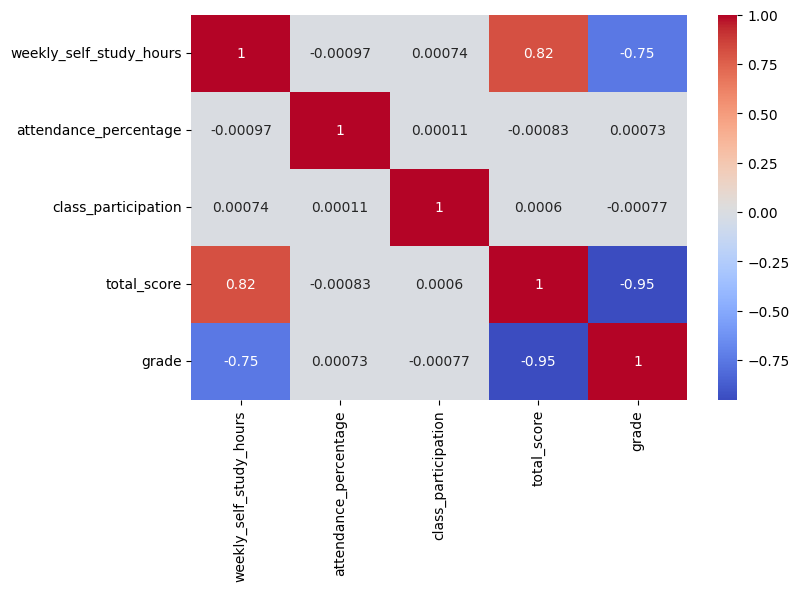

In [27]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# OBSERVATION:  
Strong corelation between total score and grade  
Study hours and attendance also positively impact performance.

# Define features & Target

In [28]:
X = df.drop('grade', axis=1)
y = df['grade']

## Train-Test split

In [29]:
# import library
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature scalling

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## OBSERVATION:  
Features and target variable are seperated  
Data split into training(80%) and testing (20%)  
Features scaled to improve model performance

# Model1 Logistic regression

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [34]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train,y_train)
y_pred1 = model1.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test,y_pred1))
print(classification_report(y_test,y_pred1))

Logistic Regression Accuracy: 0.9979212614393997
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    108047
           1       1.00      1.00      1.00     51228
           2       1.00      1.00      1.00     28103
           3       0.99      0.99      0.99      8973
           4       1.00      0.95      0.97       884

    accuracy                           1.00    197235
   macro avg       1.00      0.99      0.99    197235
weighted avg       1.00      1.00      1.00    197235



## OBSERVATION:  
Model trained succesfully   
suitable for classification problem

# Model2 Decision Tree

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [36]:
model2 = DecisionTreeClassifier()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Decision Tree Accuracy: 0.9980378736025554
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    108047
           1       1.00      1.00      1.00     51228
           2       1.00      1.00      1.00     28103
           3       0.99      1.00      1.00      8973
           4       1.00      0.99      0.99       884

    accuracy                           1.00    197235
   macro avg       1.00      1.00      1.00    197235
weighted avg       1.00      1.00      1.00    197235



## OBSERVATIION:  
This model train for comparasion    
Captures non linear patterns

# Model comparasion

In [37]:
print("Logistic Regression:", accuracy_score(y_test, y_pred1))
print("Decision Tree:", accuracy_score(y_test, y_pred2))

Logistic Regression: 0.9979212614393997
Decision Tree: 0.9980378736025554


## OBSERAVTIONS:  
Both models achieved very high accuracy (~99%).   
Decision Tree slightly outperformed Logistic Regression.   
Decision Tree is selected as the best model.


In [39]:
# save clean dataset in new csv file
df.to_csv('student_performance_cleaned.csv', index=False)
print("our clean dataset 'student_performance_cleaned.csv' is now saved !")

our clean dataset 'student_performance_cleaned.csv' is now saved !
